In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("ggplot")

In [2]:
faostat = pd.read_csv(

    "/content/FAOSTAT_data_en_7-15-2026.csv"

)

temperature = pd.read_excel(

    "/content/cru-x0.5_timeseries_tas,pr_timeseries_annual_1901-2025_mean_historical_cru_ts4.10_mean.xlsx",

    sheet_name="tas"

)

precipitation = pd.read_excel(

    "cru-x0.5_timeseries_tas,pr_timeseries_annual_1901-2025_mean_historical_cru_ts4.10_mean.xlsx",

    sheet_name="pr"

)

In [3]:
print("FAOSTAT :",faostat.shape)

print("Temperature :",temperature.shape)

print("Precipitation :",precipitation.shape)

FAOSTAT : (40366, 15)
Temperature : (246, 127)
Precipitation : (246, 127)


In [4]:
faostat.head()

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,112,Maize (corn),2005,2005,ha,261000.0,A,Official figure,NaN
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,112,Maize (corn),2005,2005,kg/ha,1206.9,A,Official figure,NaN
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,112,Maize (corn),2005,2005,t,315000.0,A,Official figure,NaN
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,112,Maize (corn),2006,2006,ha,137000.0,A,Official figure,NaN
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,112,Maize (corn),2006,2006,kg/ha,2620.4,A,Official figure,NaN


In [5]:
temperature.head()

,code,name,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,1909-07,1910-07,1911-07,1912-07,1913-07,1914-07,1915-07,1916-07,1917-07,1918-07,1919-07,1920-07,1921-07,1922-07,1923-07,1924-07,1925-07,1926-07,1927-07,1928-07,1929-07,1930-07,1931-07,1932-07,1933-07,1934-07,1935-07,1936-07,1937-07,1938-07,1939-07,1940-07,1941-07,1942-07,1943-07,1944-07,1945-07,1946-07,1947-07,1948-07,1949-07,1950-07,1951-07,1952-07,1953-07,1954-07,1955-07,1956-07,1957-07,1958-07,1959-07,1960-07,1961-07,1962-07,1963-07,1964-07,1965-07,1966-07,1967-07,1968-07,1969-07,1970-07,1971-07,1972-07,1973-07,1974-07,1975-07,1976-07,1977-07,1978-07,1979-07,1980-07,1981-07,1982-07,1983-07,1984-07,1985-07,1986-07,1987-07,1988-07,1989-07,1990-07,1991-07,1992-07,1993-07,1994-07,1995-07,1996-07,1997-07,1998-07,1999-07,2000-07,2001-07,2002-07,2003-07,2004-07,2005-07,2006-07,2007-07,2008-07,2009-07,2010-07,2011-07,2012-07,2013-07,2014-07,2015-07,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
0,ABW,Aruba (Neth.),28.22,27.79,27.89,27.62,27.68,27.58,27.56,27.46,27.52,27.52,27.59,27.65,27.48,27.57,28.35,28.10,27.80,27.82,27.63,27.50,27.65,27.52,27.94,28.10,27.82,28.35,27.84,28.00,27.82,27.98,28.31,28.51,28.37,28.49,28.18,28.41,28.34,28.04,28.29,28.84,29.02,28.74,28.20,28.12,27.94,28.07,28.65,28.28,28.03,27.57,28.24,28.50,28.38,27.88,27.81,27.77,28.30,28.97,28.48,28.67,28.37,28.33,28.46,28.35,28.26,28.51,28.12,28.28,28.83,28.47,28.03,28.62,28.71,28.09,28.11,28.05,28.66,28.76,28.65,29.17,28.79,28.66,29.16,28.38,28.25,28.31,29.00,28.47,28.15,28.07,28.66,28.94,28.95,29.02,29.23,28.89,29.19,29.54,28.85,28.70,29.11,29.10,29.26,28.89,28.95,28.89,28.90,28.59,29.01,29.20,28.66,29.15,29.39,29.46,29.67,29.68,29.27,28.97,29.37,29.41,29.06,28.88,29.43,29.59,29.38
1,AFG,Afghanistan,12.77,12.99,11.82,12.14,12.05,12.51,11.89,12.20,12.72,12.18,12.01,12.50,12.49,13.06,13.64,12.12,12.81,12.17,12.18,11.36,12.18,12.82,11.87,12.07,12.73,12.47,12.46,11.86,11.66,11.56,11.79,11.88,12.14,11.58,11.87,12.42,11.81,12.56,12.67,13.19,13.73,12.80,12.07,12.84,12.12,12.73,13.29,12.62,11.78,11.43,12.28,12.42,12.76,12.09,12.91,12.36,11.51,13.01,12.42,12.25,12.64,12.34,13.20,11.65,12.59,12.86,12.30,12.32,12.12,13.10,13.05,11.19,12.67,11.90,12.18,12.18,13.11,12.77,12.74,13.05,13.12,12.10,12.94,12.38,12.94,12.47,13.09,13.55,12.42,13.24,12.70,12.42,12.69,12.93,13.10,12.62,12.92,13.34,13.79,13.61,13.95,13.82,13.30,13.95,13.36,13.84,13.55,13.48,13.78,14.15,13.53,13.10,13.97,13.25,13.77,14.31,13.90,14.18,13.82,13.19,14.35,14.47,14.62,14.26,14.76
2,AGO,Angola,21.32,21.36,21.37,21.28,21.32,21.20,21.22,21.29,21.31,21.35,21.41,21.36,21.37,21.29,21.30,21.28,21.33,21.17,21.22,21.32,21.32,21.42,21.31,21.38,21.22,21.28,21.28,21.47,21.32,21.31,21.47,21.26,21.43,21.52,21.36,21.24,21.32,21.37,21.42,21.64,21.80,21.81,21.54,21.73,21.50,21.38,21.53,21.25,21.83,21.50,21.40,21.60,21.28,21.22,21.25,21.17,21.53,21.36,21.47,21.48,21.19,21.20,21.23,21.20,21.25,21.45,21.21,21.29,21.47,21.51,21.34,21.33,21.57,21.13,21.30,21.06,21.52,21.31,21.57,21.50,21.41,21.44,21.78,21.70,21.63,21.49,21.97,21.72,21.55,21.73,21.55,21.69,21.58,21.65,21.93,21.71,21.84,22.09,21.59,21.67,21.84,21.95,22.01,21.78,22.14,21.58,21.56,21.53,21.69,21.87,21.49,21.56,21.56,21.56,21.70,21.94,21.82,21.66,21.81,21.73,21.73,21.62,21.56,21.70,21.52
3,AIA,Anguilla (U.K.),27.17,26.74,26.80,26.29,26.68,26.42,26.09,26.24,26.17,26.23,26.15,26.47,25.92,26.27,26.90,26.50,26.03,26.22,26.42,26.15,26.02,25.97,26.62,27.01,26.37,27.02,26.79,26.70,26.26,26.50,27.20,27.17,26.88,26.62,26.55,26.80,27.00,26.59,26.80,27.33,27.36,27.45,26.88,27.09,26.61,26.75,26.99,27.02,26.71,26.58,26.76,26.83,26.74,26.49,26.47,26.30,26.72,27.26,26.93,27.01,26.79,26.83,26.98,26.90,26.82,26.99,26.70,26.89,27.36,27.07,26.65,26.86,26.94,26.71,26.68,26.61,27.13,27.06,27.12,27.52,27.46,27.16,27.74,27.24,27.32,27.43,28.07,27.68,27.36,27.67,27.62,27.64,27.80,27.66,27.86,27.65,27.86,28.32,27.79,27.81,27.97,28.18,28.11,27.76,28.08,27.84,27.83,27.44,27.80,28.16,27.76,

In [6]:
precipitation.head()

,code,name,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,1909-07,1910-07,1911-07,1912-07,1913-07,1914-07,1915-07,1916-07,1917-07,1918-07,1919-07,1920-07,1921-07,1922-07,1923-07,1924-07,1925-07,1926-07,1927-07,1928-07,1929-07,1930-07,1931-07,1932-07,1933-07,1934-07,1935-07,1936-07,1937-07,1938-07,1939-07,1940-07,1941-07,1942-07,1943-07,1944-07,1945-07,1946-07,1947-07,1948-07,1949-07,1950-07,1951-07,1952-07,1953-07,1954-07,1955-07,1956-07,1957-07,1958-07,1959-07,1960-07,1961-07,1962-07,1963-07,1964-07,1965-07,1966-07,1967-07,1968-07,1969-07,1970-07,1971-07,1972-07,1973-07,1974-07,1975-07,1976-07,1977-07,1978-07,1979-07,1980-07,1981-07,1982-07,1983-07,1984-07,1985-07,1986-07,1987-07,1988-07,1989-07,1990-07,1991-07,1992-07,1993-07,1994-07,1995-07,1996-07,1997-07,1998-07,1999-07,2000-07,2001-07,2002-07,2003-07,2004-07,2005-07,2006-07,2007-07,2008-07,2009-07,2010-07,2011-07,2012-07,2013-07,2014-07,2015-07,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
0,ABW,Aruba (Neth.),420.90,420.90,420.90,420.90,420.90,420.90,420.90,420.90,420.90,420.90,569.70,487.00,413.30,393.80,379.90,442.30,447.70,434.30,253.30,324.10,363.10,503.10,367.70,574.00,275.70,446.40,624.10,486.30,342.80,305.50,498.50,475.70,535.40,439.20,483.30,455.90,558.60,544.80,430.10,288.40,218.80,620.70,443.20,479.40,305.10,378.80,314.10,310.70,438.50,574.50,393.00,375.00,306.40,380.30,535.60,599.50,303.80,219.20,274.40,376.50,403.50,342.20,477.00,328.20,373.90,667.60,350.00,316.50,617.10,612.20,298.70,455.90,446.40,384.60,513.50,261.40,217.70,300.60,563.80,311.60,648.30,334.80,272.90,413.00,641.30,354.20,391.50,591.20,362.10,463.20,310.40,383.60,290.60,367.60,383.90,501.80,254.30,426.20,707.50,484.30,346.30,266.80,392.90,643.20,658.10,500.80,418.10,624.20,333.30,697.90,684.30,357.10,327.60,282.40,281.30,440.50,375.60,467.20,218.30,394.20,420.90,420.90,415.40,444.80,488.20
1,AFG,Afghanistan,289.67,269.70,331.11,315.35,285.52,305.15,314.33,332.24,301.74,316.70,313.92,310.50,296.92,360.02,281.05,292.44,197.97,307.63,324.47,313.30,304.11,315.73,338.86,381.61,258.26,321.97,264.55,287.12,289.35,307.49,383.95,303.98,339.24,342.76,328.14,303.70,318.28,319.73,355.71,297.51,319.02,358.89,351.29,314.75,345.01,252.41,268.91,301.61,297.93,295.53,330.10,326.03,383.89,343.19,295.31,363.04,443.93,326.60,368.82,363.89,345.95,277.44,351.40,335.61,377.70,295.40,380.33,357.10,372.29,242.56,201.95,415.69,285.06,313.66,337.12,375.29,310.99,306.62,351.83,357.34,365.37,429.05,319.31,276.26,248.02,329.15,316.73,334.57,324.80,361.26,429.73,403.99,329.92,337.75,313.38,330.82,333.33,372.40,315.96,240.34,233.14,311.86,343.76,312.42,374.20,349.02,321.83,290.55,390.40,297.47,321.52,374.70,368.17,305.86,407.70,368.40,307.58,274.83,396.27,394.98,232.26,300.98,292.42,355.05,254.39
2,AGO,Angola,1021.18,1038.05,1060.12,980.71,978.53,1067.39,1019.09,1024.27,1155.25,1053.64,978.89,1143.70,984.00,889.27,928.09,1102.03,982.84,1011.10,1012.73,1031.54,1062.74,993.81,1209.13,1092.34,1072.55,1088.60,1014.75,957.96,1012.23,882.28,1043.35,923.49,1074.49,1154.88,1054.84,1020.33,1158.02,1047.39,1020.67,1003.98,932.48,980.97,983.41,1182.40,1109.46,976.63,1102.93,992.31,991.60,1171.69,1221.16,1053.58,1001.33,1119.37,1086.43,1041.11,1167.38,911.78,1087.92,1173.81,1236.29,1135.08,1117.91,959.81,996.79,1133.91,1199.32,1126.73,1220.30,965.98,999.10,984.89,1064.23,1094.06,1041.18,1105.11,1111.27,1045.71,1123.22,941.74,886.16,975.58,947.99,964.94,987.33,1134.69,995.32,1091.43,971.59,1035.08,1078.70,930.54,1034.39,984.49,955.03,989.76,1079.46,1029.85,1060.74,1053.39,1043.69,1076.96,1022.52,1059.90,1011.95,1083.29,1045.72,1061.30,1062.04,1039.62,1086.99,1071.81,1004.40,1052.58,993.92,1013.76,1071.16,1056.66,1063.28,1071.06,1058.26,1057.70,1053.24,1027.79,1068.87
3,AIA,Anguilla (U.K.),1227.30,1096.20,1028.90,1072.00,1097.20,1018.00,970.40,1033.70,1120.90,1114.50,1102.60,944.60,1003.60,1026.60,1065.90,1132.00,947.40,956.30,1044.70,976.10,1014.60,1010.10,890.50,1053.60,912.10,957.80,10

In [7]:
print(faostat.columns)

print()

print(temperature.columns)

print()

print(precipitation.columns)

Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description', 'Note'],
      dtype='object')

Index(['code', 'name', '1901-07', '1902-07', '1903-07', '1904-07', '1905-07',
       '1906-07', '1907-07', '1908-07',
       ...
       '2016-07', '2017-07', '2018-07', '2019-07', '2020-07', '2021-07',
       '2022-07', '2023-07', '2024-07', '2025-07'],
      dtype='object', length=127)

Index(['code', 'name', '1901-07', '1902-07', '1903-07', '1904-07', '1905-07',
       '1906-07', '1907-07', '1908-07',
       ...
       '2016-07', '2017-07', '2018-07', '2019-07', '2020-07', '2021-07',
       '2022-07', '2023-07', '2024-07', '2025-07'],
      dtype='object', length=127)


In [8]:
faostat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40366 entries, 0 to 40365
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       40366 non-null  object 
 1   Domain            40366 non-null  object 
 2   Area Code (M49)   40366 non-null  int64  
 3   Area              40366 non-null  object 
 4   Element Code      40366 non-null  int64  
 5   Element           40366 non-null  object 
 6   Item Code (CPC)   40366 non-null  int64  
 7   Item              40366 non-null  object 
 8   Year Code         40366 non-null  int64  
 9   Year              40366 non-null  int64  
 10  Unit              40366 non-null  object 
 11  Value             39787 non-null  float64
 12  Flag              40366 non-null  object 
 13  Flag Description  40366 non-null  object 
 14  Note              849 non-null    object 
dtypes: float64(1), int64(5), object(9)
memory usage: 4.6+ MB


In [9]:
temperature.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Columns: 127 entries, code to 2025-07
dtypes: float64(125), object(2)
memory usage: 244.2+ KB


In [10]:
precipitation.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Columns: 127 entries, code to 2025-07
dtypes: float64(125), object(2)
memory usage: 244.2+ KB


In [11]:
faostat.isnull().sum()

,0
Domain Code,0
Domain,0
Area Code (M49),0
Area,0
Element Code,0
Element,0
Item Code (CPC),0
Item,0
Year Code,0
Year,0


In [12]:
temperature.isnull().sum()

,0
code,0
name,0
1901-07,2
1902-07,2
1903-07,2
...,...
2021-07,2
2022-07,2
2023-07,2
2024-07,2


In [13]:
precipitation.isnull().sum()

,0
code,0
name,0
1901-07,2
1902-07,2
1903-07,2
...,...
2021-07,2
2022-07,2
2023-07,2
2024-07,2


In [14]:
print("FAOSTAT :",faostat.duplicated().sum())

print("Temperature :",temperature.duplicated().sum())

print("Precipitation :",precipitation.duplicated().sum())

FAOSTAT : 0
Temperature : 0
Precipitation : 0


In [15]:
faostat.describe(include='all')

,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
count,40366,40366,40366.000000,40366,40366.000000,40366,40366.000000,40366,40366.000000,40366.000000,40366,3.978700e+04,40366,40366,849
unique,1,1,NaN,195,NaN,3,NaN,5,NaN,NaN,3,NaN,5,5,1
top,QCL,Crops and livestock products,NaN,Afghanistan,NaN,Production,NaN,Maize (corn),NaN,NaN,t,NaN,A,Official figure,Unofficial figure
freq,40366,40366,NaN,300,NaN,13647,NaN,9947,NaN,NaN,13647,NaN,30588,30588,849
mean,NaN,NaN,423.899569,NaN,5411.336224,NaN,691.698608,NaN,2014.558044,2014.558044,NaN,3.049809e+06,NaN,NaN,NaN
std,NaN,NaN,255.235292,NaN,81.401693,NaN,740.570500,NaN,5.779956,5.779956,NaN,2.353867e+07,NaN,NaN,NaN
min,NaN,NaN,4.000000,NaN,5312.000000,NaN,111.000000,NaN,2005.000000,2005.000000,NaN,0.000000e+00,NaN,NaN,NaN
25%,NaN,NaN,192.000000,NaN,5312.000000,NaN,112.000000,NaN,2010.000000,2010.000000,NaN,3.935150e+03,NaN,NaN,NaN
50%,NaN,NaN,414.000000,NaN,5412.000000,NaN,113.000000,NaN,2015.000000,2015.000000,NaN,2.915490e+04,NaN,NaN,NaN
75%,NaN,NaN,642.000000,NaN,5510.000000,NaN,1510.000000,NaN,2020.000000,2020.000000,NaN,3.604500e+05,NaN,NaN,NaN


In [16]:
temperature.describe()

,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,1909-07,1910-07,1911-07,1912-07,1913-07,1914-07,1915-07,1916-07,1917-07,1918-07,1919-07,1920-07,1921-07,1922-07,1923-07,1924-07,1925-07,1926-07,1927-07,1928-07,1929-07,1930-07,1931-07,1932-07,1933-07,1934-07,1935-07,1936-07,1937-07,1938-07,1939-07,1940-07,1941-07,1942-07,1943-07,1944-07,1945-07,1946-07,1947-07,1948-07,1949-07,1950-07,1951-07,1952-07,1953-07,1954-07,1955-07,1956-07,1957-07,1958-07,1959-07,1960-07,1961-07,1962-07,1963-07,1964-07,1965-07,1966-07,1967-07,1968-07,1969-07,1970-07,1971-07,1972-07,1973-07,1974-07,1975-07,1976-07,1977-07,1978-07,1979-07,1980-07,1981-07,1982-07,1983-07,1984-07,1985-07,1986-07,1987-07,1988-07,1989-07,1990-07,1991-07,1992-07,1993-07,1994-07,1995-07,1996-07,1997-07,1998-07,1999-07,2000-07,2001-07,2002-07,2003-07,2004-07,2005-07,2006-07,2007-07,2008-07,2009-07,2010-07,2011-07,2012-07,2013-07,2014-07,2015-07,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,243.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,18.937336,18.767910,18.842910,18.735082,18.815533,18.864180,18.612541,18.714631,18.755082,18.796844,18.804098,18.755738,18.820492,18.904549,18.931967,18.888484,18.648484,18.794508,18.788689,18.881844,18.937254,18.803566,18.924467,18.891516,18.986543,19.088689,18.976434,18.942254,18.718197,19.016557,18.918279,19.006230,18.819262,19.106803,18.984303,19.032910,19.164590,19.129713,19.066107,18.856434,19.031393,18.969098,19.033607,19.085164,19.004590,19.098115,19.189057,19.079467,19.072705,18.922336,19.064344,19.060328,19.097172,18.844262,18.912992,18.565697,19.011393,19.205779,19.103770,19.124918,19.152172,18.928852,18.923689,18.808852,18.754549,19.123074,18.874098,18.847869,19.020574,19.037541,18.847459,18.896598,19.106393,18.872910,18.993320,18.728607,19.116434,18.965779,19.174016,19.078484,19.187090,19.152377,19.403443,19.056434,18.999713,19.113074,19.293525,19.357828,19.334508,19.584959,19.318156,19.263770,19.232787,19.530492,19.515656,19.220738,19.510410,19.824836,19.663238,19.650287,19.715082,19.830574,19.749385,19.675328,19.708770,19.761066,19.835656,19.677664,19.828238,19.831393,19.703607,19.735615,19.783238,19.965082,20.085861,20.111352,19.989098,20.020574,20.124139,20.146311,19.998402,20.052254,20.380492,20.489016,20.247910
std,8.802881,9.026771,8.784587,8.792531,8.809226,8.737719,8.890308,8.878203,8.866049,8.649840,8.664988,8.933905,8.663298,8.736135,8.886425,8.718224,8.895606,8.726931,8.948802,8.658750,8.630252,8.835686,8.705893,8.851418,8.563071,8.697074,8.723604,8.741519,8.819223,8.511554,8.897079,8.697789,8.863477,8.482672,8.709604,8.658146,8.645935,8.540413,8.605712,9.033300

In [17]:
precipitation.describe()

,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,1909-07,1910-07,1911-07,1912-07,1913-07,1914-07,1915-07,1916-07,1917-07,1918-07,1919-07,1920-07,1921-07,1922-07,1923-07,1924-07,1925-07,1926-07,1927-07,1928-07,1929-07,1930-07,1931-07,1932-07,1933-07,1934-07,1935-07,1936-07,1937-07,1938-07,1939-07,1940-07,1941-07,1942-07,1943-07,1944-07,1945-07,1946-07,1947-07,1948-07,1949-07,1950-07,1951-07,1952-07,1953-07,1954-07,1955-07,1956-07,1957-07,1958-07,1959-07,1960-07,1961-07,1962-07,1963-07,1964-07,1965-07,1966-07,1967-07,1968-07,1969-07,1970-07,1971-07,1972-07,1973-07,1974-07,1975-07,1976-07,1977-07,1978-07,1979-07,1980-07,1981-07,1982-07,1983-07,1984-07,1985-07,1986-07,1987-07,1988-07,1989-07,1990-07,1991-07,1992-07,1993-07,1994-07,1995-07,1996-07,1997-07,1998-07,1999-07,2000-07,2001-07,2002-07,2003-07,2004-07,2005-07,2006-07,2007-07,2008-07,2009-07,2010-07,2011-07,2012-07,2013-07,2014-07,2015-07,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
count,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000,244.000000
mean,1271.431680,1242.583730,1265.280615,1256.426885,1248.832705,1251.295369,1206.469713,1244.395205,1271.147664,1286.648033,1236.512295,1233.754590,1234.913689,1243.327172,1292.392418,1318.807336,1273.309549,1254.347049,1253.654754,1246.160287,1231.228484,1266.230492,1254.169795,1280.271107,1250.133811,1241.716270,1293.829590,1287.577746,1244.492090,1232.285820,1274.103770,1261.776025,1291.369262,1259.655615,1274.118525,1296.186557,1264.146189,1280.864836,1266.896967,1236.079795,1236.220984,1260.781025,1241.283197,1255.735410,1231.186516,1224.136393,1238.272377,1294.294713,1233.818238,1283.547951,1302.786680,1291.690861,1262.615123,1324.896393,1334.764180,1300.978484,1243.167254,1265.419877,1248.923566,1311.257787,1288.679795,1275.417746,1279.324795,1227.904795,1252.537213,1312.308607,1257.581885,1243.302664,1296.264344,1303.253730,1218.291516,1270.656189,1222.161516,1272.124426,1254.576967,1232.749344,1214.052049,1262.236189,1323.137500,1274.688525,1310.780205,1249.242049,1182.231516,1270.665533,1230.679508,1241.192582,1256.752705,1312.986025,1246.858402,1226.699139,1209.533525,1226.478852,1227.952910,1208.734221,1243.701352,1281.643484,1216.450205,1270.448320,1296.720451,1261.398893,1241.763730,1252.827746,1251.632787,1257.129754,1289.801189,1292.678525,1279.688648,1307.550697,1237.187623,1346.571598,1316.465205,1266.527336,1266.641803,1263.374180,1190.239795,1275.904959,1299.680000,1275.373525,1244.404508,1281.885369,1262.328934,1285.312869,1297.507377,1308.367746,1277.265369
std,832.049292,817.469737,835.426942,837.018076,812.407589,810.434523,803.229952,869.850667,823.182406,838.965318

In [18]:
print("Countries :")

print(faostat["Area"].nunique())

Countries :
195


In [19]:
print("Crop Types :")

print(faostat["Item"].nunique())

Crop Types :
5


In [20]:
sorted(
    faostat["Item"].unique()
)

['Maize (corn)', 'Potatoes', 'Rice', 'Sugar cane', 'Wheat']

In [21]:
faostat["Element"].value_counts()

,count
Element,
Production,13647
Area harvested,13642
Yield,13077


In [22]:
faostat["Unit"].value_counts()

,count
Unit,
t,13647
ha,13642
kg/ha,13077


In [23]:
print(

faostat["Year"].min(),

faostat["Year"].max()

)

2005 2024


Top 15 Countries by Records

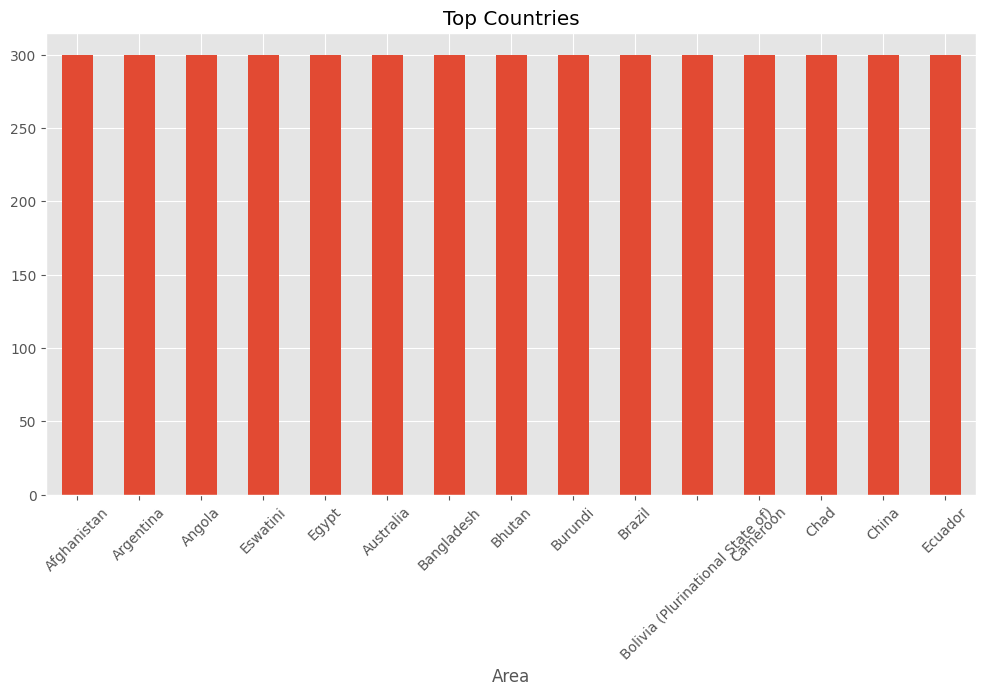

In [24]:
plt.figure(figsize=(12,6))

faostat["Area"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Top Countries")

plt.xticks(rotation=45)

plt.show()

Most Common Crops

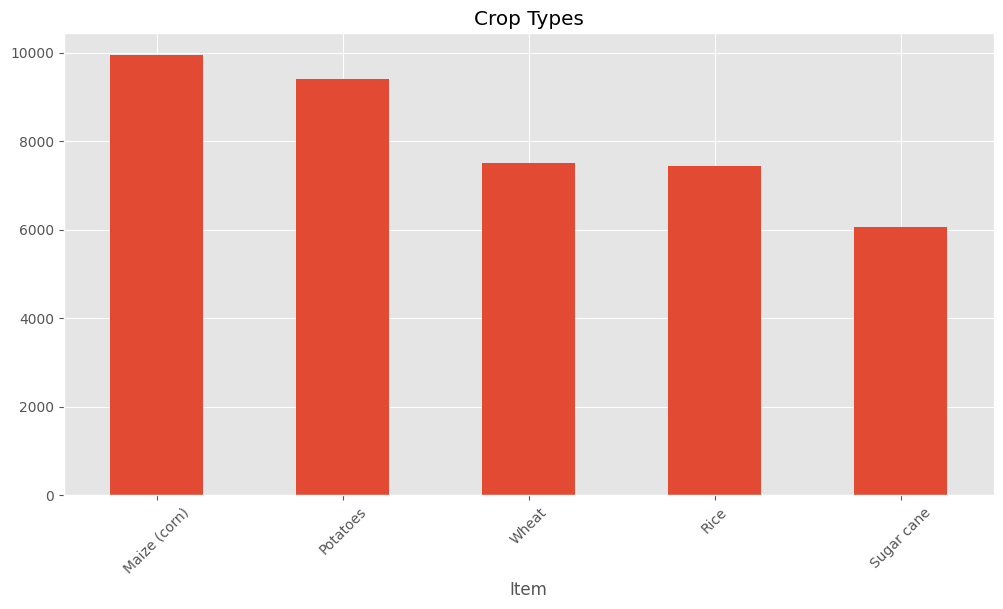

In [25]:
plt.figure(figsize=(12,6))

faostat["Item"].value_counts().head(15).plot(
    kind="bar"
)

plt.title("Crop Types")

plt.xticks(rotation=45)

plt.show()

Distribution of Elements

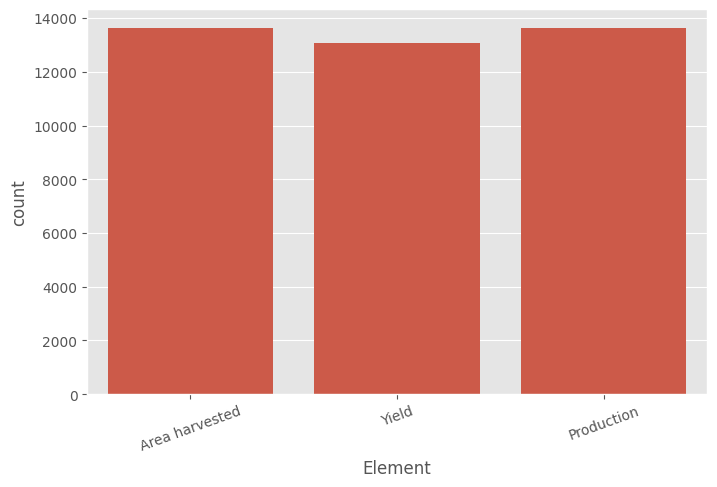

In [26]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=faostat,
    x="Element"
)

plt.xticks(rotation=20)

plt.show()

Records Per Year

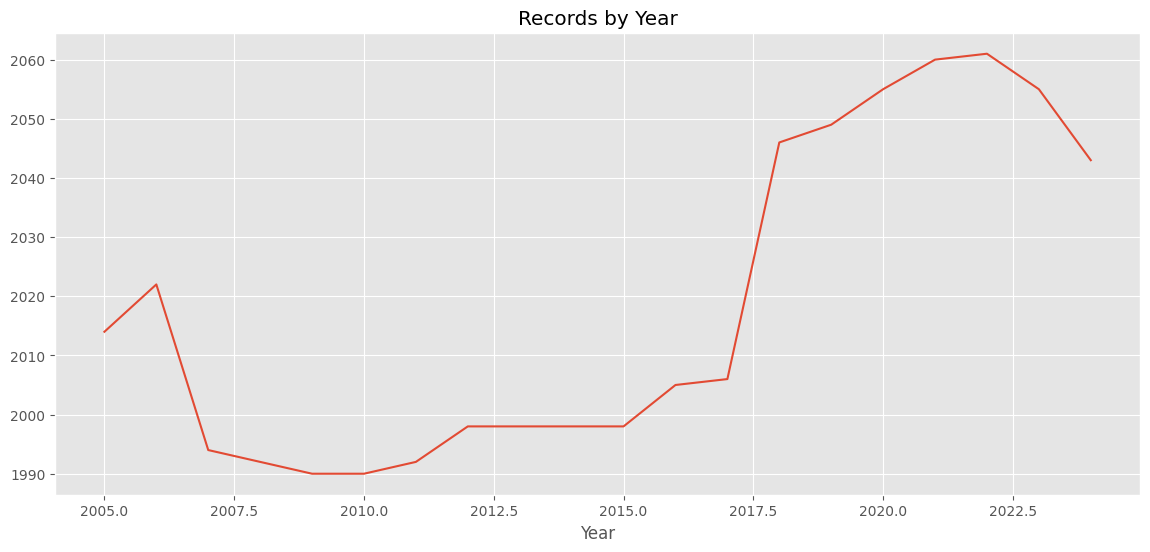

In [27]:
plt.figure(figsize=(14,6))

faostat["Year"].value_counts().sort_index().plot()

plt.title("Records by Year")

plt.show()

In [28]:
temperature.head()

,code,name,1901-07,1902-07,1903-07,1904-07,1905-07,1906-07,1907-07,1908-07,1909-07,1910-07,1911-07,1912-07,1913-07,1914-07,1915-07,1916-07,1917-07,1918-07,1919-07,1920-07,1921-07,1922-07,1923-07,1924-07,1925-07,1926-07,1927-07,1928-07,1929-07,1930-07,1931-07,1932-07,1933-07,1934-07,1935-07,1936-07,1937-07,1938-07,1939-07,1940-07,1941-07,1942-07,1943-07,1944-07,1945-07,1946-07,1947-07,1948-07,1949-07,1950-07,1951-07,1952-07,1953-07,1954-07,1955-07,1956-07,1957-07,1958-07,1959-07,1960-07,1961-07,1962-07,1963-07,1964-07,1965-07,1966-07,1967-07,1968-07,1969-07,1970-07,1971-07,1972-07,1973-07,1974-07,1975-07,1976-07,1977-07,1978-07,1979-07,1980-07,1981-07,1982-07,1983-07,1984-07,1985-07,1986-07,1987-07,1988-07,1989-07,1990-07,1991-07,1992-07,1993-07,1994-07,1995-07,1996-07,1997-07,1998-07,1999-07,2000-07,2001-07,2002-07,2003-07,2004-07,2005-07,2006-07,2007-07,2008-07,2009-07,2010-07,2011-07,2012-07,2013-07,2014-07,2015-07,2016-07,2017-07,2018-07,2019-07,2020-07,2021-07,2022-07,2023-07,2024-07,2025-07
0,ABW,Aruba (Neth.),28.22,27.79,27.89,27.62,27.68,27.58,27.56,27.46,27.52,27.52,27.59,27.65,27.48,27.57,28.35,28.10,27.80,27.82,27.63,27.50,27.65,27.52,27.94,28.10,27.82,28.35,27.84,28.00,27.82,27.98,28.31,28.51,28.37,28.49,28.18,28.41,28.34,28.04,28.29,28.84,29.02,28.74,28.20,28.12,27.94,28.07,28.65,28.28,28.03,27.57,28.24,28.50,28.38,27.88,27.81,27.77,28.30,28.97,28.48,28.67,28.37,28.33,28.46,28.35,28.26,28.51,28.12,28.28,28.83,28.47,28.03,28.62,28.71,28.09,28.11,28.05,28.66,28.76,28.65,29.17,28.79,28.66,29.16,28.38,28.25,28.31,29.00,28.47,28.15,28.07,28.66,28.94,28.95,29.02,29.23,28.89,29.19,29.54,28.85,28.70,29.11,29.10,29.26,28.89,28.95,28.89,28.90,28.59,29.01,29.20,28.66,29.15,29.39,29.46,29.67,29.68,29.27,28.97,29.37,29.41,29.06,28.88,29.43,29.59,29.38
1,AFG,Afghanistan,12.77,12.99,11.82,12.14,12.05,12.51,11.89,12.20,12.72,12.18,12.01,12.50,12.49,13.06,13.64,12.12,12.81,12.17,12.18,11.36,12.18,12.82,11.87,12.07,12.73,12.47,12.46,11.86,11.66,11.56,11.79,11.88,12.14,11.58,11.87,12.42,11.81,12.56,12.67,13.19,13.73,12.80,12.07,12.84,12.12,12.73,13.29,12.62,11.78,11.43,12.28,12.42,12.76,12.09,12.91,12.36,11.51,13.01,12.42,12.25,12.64,12.34,13.20,11.65,12.59,12.86,12.30,12.32,12.12,13.10,13.05,11.19,12.67,11.90,12.18,12.18,13.11,12.77,12.74,13.05,13.12,12.10,12.94,12.38,12.94,12.47,13.09,13.55,12.42,13.24,12.70,12.42,12.69,12.93,13.10,12.62,12.92,13.34,13.79,13.61,13.95,13.82,13.30,13.95,13.36,13.84,13.55,13.48,13.78,14.15,13.53,13.10,13.97,13.25,13.77,14.31,13.90,14.18,13.82,13.19,14.35,14.47,14.62,14.26,14.76
2,AGO,Angola,21.32,21.36,21.37,21.28,21.32,21.20,21.22,21.29,21.31,21.35,21.41,21.36,21.37,21.29,21.30,21.28,21.33,21.17,21.22,21.32,21.32,21.42,21.31,21.38,21.22,21.28,21.28,21.47,21.32,21.31,21.47,21.26,21.43,21.52,21.36,21.24,21.32,21.37,21.42,21.64,21.80,21.81,21.54,21.73,21.50,21.38,21.53,21.25,21.83,21.50,21.40,21.60,21.28,21.22,21.25,21.17,21.53,21.36,21.47,21.48,21.19,21.20,21.23,21.20,21.25,21.45,21.21,21.29,21.47,21.51,21.34,21.33,21.57,21.13,21.30,21.06,21.52,21.31,21.57,21.50,21.41,21.44,21.78,21.70,21.63,21.49,21.97,21.72,21.55,21.73,21.55,21.69,21.58,21.65,21.93,21.71,21.84,22.09,21.59,21.67,21.84,21.95,22.01,21.78,22.14,21.58,21.56,21.53,21.69,21.87,21.49,21.56,21.56,21.56,21.70,21.94,21.82,21.66,21.81,21.73,21.73,21.62,21.56,21.70,21.52
3,AIA,Anguilla (U.K.),27.17,26.74,26.80,26.29,26.68,26.42,26.09,26.24,26.17,26.23,26.15,26.47,25.92,26.27,26.90,26.50,26.03,26.22,26.42,26.15,26.02,25.97,26.62,27.01,26.37,27.02,26.79,26.70,26.26,26.50,27.20,27.17,26.88,26.62,26.55,26.80,27.00,26.59,26.80,27.33,27.36,27.45,26.88,27.09,26.61,26.75,26.99,27.02,26.71,26.58,26.76,26.83,26.74,26.49,26.47,26.30,26.72,27.26,26.93,27.01,26.79,26.83,26.98,26.90,26.82,26.99,26.70,26.89,27.36,27.07,26.65,26.86,26.94,26.71,26.68,26.61,27.13,27.06,27.12,27.52,27.46,27.16,27.74,27.24,27.32,27.43,28.07,27.68,27.36,27.67,27.62,27.64,27.80,27.66,27.86,27.65,27.86,28.32,27.79,27.81,27.97,28.18,28.11,27.76,28.08,27.84,27.83,27.44,27.80,28.16,27.76,

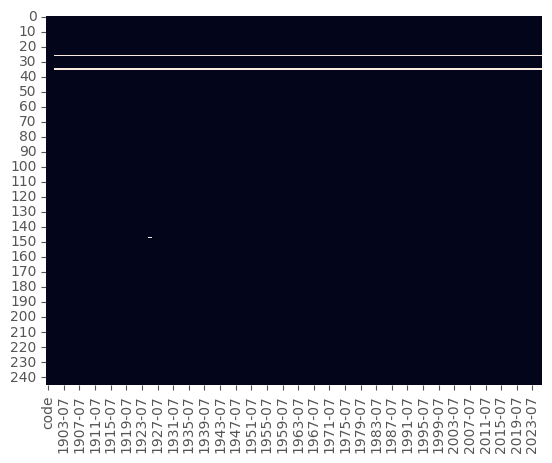

In [29]:
sns.heatmap(
    temperature.isnull(),
    cbar=False
)

plt.show()

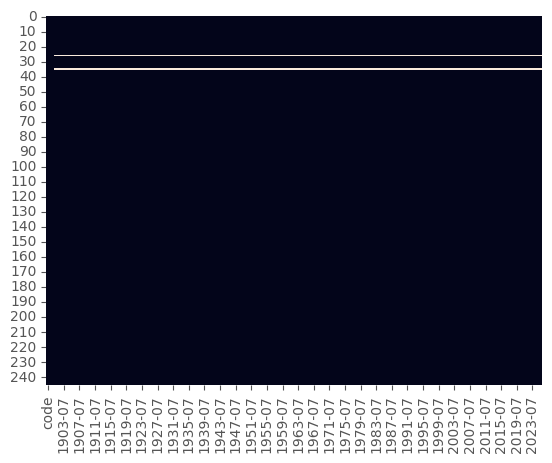

In [30]:
sns.heatmap(
    precipitation.isnull(),
    cbar=False
)

plt.show()

In [31]:
!pip install geopy pycountry requests -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 48.0 MB/s eta 0:00:00


In [32]:
import requests
import pandas as pd
from geopy.geocoders import Nominatim
from time import sleep

In [33]:
countries = (
    faostat["Area"]
    .drop_duplicates()
    .sort_values()
    .tolist()
)

print("Number of countries:", len(countries))

Number of countries: 195


In [34]:
geolocator = Nominatim(user_agent="soilgrids_project")

country_locations = []

for country in countries:

    try:

        location = geolocator.geocode(country)

        if location:

            country_locations.append({
                "Country": country,
                "Latitude": location.latitude,
                "Longitude": location.longitude
            })

        sleep(1)

    except:
        pass

country_locations = pd.DataFrame(country_locations)

country_locations.head()

,Country,Latitude,Longitude
0,Afghanistan,33.768006,66.238514
1,Albania,41.179348,19.882419
2,Algeria,36.772933,3.058845
3,Angola,-11.877577,17.569124
4,Antigua and Barbuda,17.223472,-61.955461


In [35]:
temperature_long = temperature.melt(
    id_vars=["code", "name"],
    var_name="Year",
    value_name="Temperature"
)

temperature_long.head()

,code,name,Year,Temperature
0,ABW,Aruba (Neth.),1901-07,28.22
1,AFG,Afghanistan,1901-07,12.77
2,AGO,Angola,1901-07,21.32
3,AIA,Anguilla (U.K.),1901-07,27.17
4,ALA,ALA,1901-07,5.39


In [36]:
temperature_long.rename(
    columns={"name": "Area"},
    inplace=True
)

In [37]:
temperature_long["Year"] = (
    temperature_long["Year"]
    .str[:4]
    .astype(int)
)

In [38]:
precipitation_long = precipitation.melt(
    id_vars=["code", "name"],
    var_name="Year",
    value_name="Precipitation"
)

precipitation_long.rename(
    columns={"name": "Area"},
    inplace=True
)

precipitation_long["Year"] = (
    precipitation_long["Year"]
    .str[:4]
    .astype(int)
)

precipitation_long.head()

,code,Area,Year,Precipitation
0,ABW,Aruba (Neth.),1901,420.90
1,AFG,Afghanistan,1901,289.67
2,AGO,Angola,1901,1021.18
3,AIA,Anguilla (U.K.),1901,1227.30
4,ALA,ALA,1901,365.26


In [39]:
print("Temperature Countries:", temperature_long["Area"].nunique())

print("Precipitation Countries:", precipitation_long["Area"].nunique())

Temperature Countries: 246
Precipitation Countries: 246


In [40]:
climate = pd.merge(
    temperature_long,
    precipitation_long,
    on=["code", "Area", "Year"],
    how="inner"
)

climate.head()

,code,Area,Year,Temperature,Precipitation
0,ABW,Aruba (Neth.),1901,28.22,420.90
1,AFG,Afghanistan,1901,12.77,289.67
2,AGO,Angola,1901,21.32,1021.18
3,AIA,Anguilla (U.K.),1901,27.17,1227.30
4,ALA,ALA,1901,5.39,365.26


In [41]:
print(faostat["Area"].sort_values().unique()[:20])

print(climate["Area"].sort_values().unique()[:20])

['Afghanistan' 'Albania' 'Algeria' 'Angola' 'Antigua and Barbuda'
 'Argentina' 'Armenia' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin'
 'Bhutan' 'Bolivia (Plurinational State of)']
['ALA' 'Afghanistan' 'Albania' 'Algeria' 'American Samoa (U.S.)' 'Andorra'
 'Angola' 'Anguilla (U.K.)' 'Antigua and Barbuda' 'Arab Republic of Egypt'
 'Argentina' 'Armenia' 'Aruba (Neth.)' 'Australia' 'Austria' 'Azerbaijan'
 'Bahrain' 'Bangladesh' 'Barbados' 'Belarus']


In [42]:
faostat_countries = set(faostat["Area"].unique())
climate_countries = set(climate["Area"].unique())

print("Countries in FAOSTAT but not Climate:")
print(sorted(faostat_countries - climate_countries))

print("\nCountries in Climate but not FAOSTAT:")
print(sorted(climate_countries - faostat_countries))

Countries in FAOSTAT but not Climate:
['Bahamas', 'Bolivia (Plurinational State of)', 'China, Hong Kong SAR', 'China, Taiwan Province of', 'China, mainland', 'Czechia', "Democratic People's Republic of Korea", 'Democratic Republic of the Congo', 'Egypt', 'Faroe Islands', 'French Guiana', 'French Polynesia', 'Gambia', 'Guadeloupe', 'Iran (Islamic Republic of)', 'Kyrgyzstan', 'Martinique', 'Micronesia (Federated States of)', 'Netherlands (Kingdom of the)', 'New Caledonia', 'Palestine', 'Puerto Rico', 'Republic of Moldova', 'Réunion', 'Sao Tome and Principe', 'Serbia and Montenegro', 'Slovakia', 'Sudan (former)', 'United Kingdom of Great Britain and Northern Ireland', 'United Republic of Tanzania', 'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Yemen']

Countries in Climate but not FAOSTAT:
['ALA', 'American Samoa (U.S.)', 'Andorra', 'Anguilla (U.K.)', 'Arab Republic of Egypt', 'Aruba (Neth.)', 'Bermuda (U.K.)', 'Bolivia', 'Bonaire, Sint Eustatius and Saba', 'Bouvet Island (Nor.)', 'B

In [43]:
country_mapping = {
    "Arab Republic of Egypt": "Egypt",
    "Iran (Islamic Republic of)": "Iran (Islamic Republic of)",
    "Russian Federation": "Russian Federation",
    "Türkiye": "Turkey",
    "United Republic of Tanzania": "United Republic of Tanzania",
    "Venezuela (Bolivarian Republic of)": "Venezuela (Bolivarian Republic of)",
    "Bolivia": "Bolivia (Plurinational State of)",
    "Aruba (Neth.)": "Aruba",
}

In [44]:
climate["Area"] = climate["Area"].replace(country_mapping)

In [45]:
faostat_countries = set(faostat["Area"].unique())
climate_countries = set(climate["Area"].unique())

print("Remaining unmatched countries:")
print(sorted(faostat_countries - climate_countries))

Remaining unmatched countries:
['Bahamas', 'China, Hong Kong SAR', 'China, Taiwan Province of', 'China, mainland', 'Czechia', "Democratic People's Republic of Korea", 'Democratic Republic of the Congo', 'Faroe Islands', 'French Guiana', 'French Polynesia', 'Gambia', 'Guadeloupe', 'Iran (Islamic Republic of)', 'Kyrgyzstan', 'Martinique', 'Micronesia (Federated States of)', 'Netherlands (Kingdom of the)', 'New Caledonia', 'Palestine', 'Puerto Rico', 'Republic of Moldova', 'Réunion', 'Sao Tome and Principe', 'Serbia and Montenegro', 'Slovakia', 'Sudan (former)', 'Türkiye', 'United Kingdom of Great Britain and Northern Ireland', 'United Republic of Tanzania', 'Venezuela (Bolivarian Republic of)', 'Viet Nam', 'Yemen']


In [46]:
country_mapping = {

    "Bahamas": "Bahamas, The",

    "China, Hong Kong SAR": "Hong Kong SAR, China",

    "China, Taiwan Province of": "Taiwan, China",

    "China, mainland": "China",

    "Czechia": "Czech Republic",

    "Democratic People's Republic of Korea": "Korea, Dem. People's Rep.",

    "Democratic Republic of the Congo": "Congo, Dem. Rep.",

    "Faroe Islands": "Faroe Islands (Den.)",

    "French Guiana": "French Guiana (Fr.)",

    "French Polynesia": "French Polynesia (Fr.)",

    "Gambia": "Gambia, The",

    "Guadeloupe": "Guadeloupe (Fr.)",

    "Iran (Islamic Republic of)": "Iran",

    "Kyrgyzstan": "Kyrgyz Republic",

    "Martinique": "Martinique (Fr.)",

    "Micronesia (Federated States of)": "Micronesia, Fed. Sts.",

    "Netherlands (Kingdom of the)": "Netherlands",

    "New Caledonia": "New Caledonia (Fr.)",

    "Palestine": "West Bank and Gaza",

    "Puerto Rico": "Puerto Rico (U.S.)",

    "Republic of Moldova": "Moldova",

    "Réunion": "Réunion (Fr.)",

    "Sao Tome and Principe": "São Tomé and Príncipe",

    "Türkiye": "Turkey",

    "United Kingdom of Great Britain and Northern Ireland": "United Kingdom",

    "United Republic of Tanzania": "Tanzania",

    "Venezuela (Bolivarian Republic of)": "Venezuela",

    "Viet Nam": "Vietnam",

    "Yemen": "Yemen, Rep."

}

faostat["Area"] = faostat["Area"].replace(country_mapping)

In [47]:
faostat_countries = set(faostat["Area"].unique())
climate_countries = set(climate["Area"].unique())

print(sorted(faostat_countries - climate_countries))

['Bahamas, The', 'Congo, Dem. Rep.', 'French Guiana (Fr.)', 'Gambia, The', 'Guadeloupe (Fr.)', 'Hong Kong SAR, China', 'Iran', "Korea, Dem. People's Rep.", 'Martinique (Fr.)', 'Micronesia, Fed. Sts.', 'Réunion (Fr.)', 'Serbia and Montenegro', 'Slovakia', 'Sudan (former)', 'Taiwan, China', 'Venezuela', 'Yemen, Rep.']


In [48]:
faostat = faostat[
    ~faostat["Area"].isin([
        "Serbia and Montenegro",
        "Sudan (former)"
    ])
]

In [49]:
climate = climate[
    (climate["Year"] >= 2005) &
    (climate["Year"] <= 2024)
]

In [51]:
merged = pd.merge(
    faostat,
    climate,
    on=["Area", "Year"],
    how="inner"
)

print(merged.shape)
merged.head()

(38010, 18)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note,code,Temperature,Precipitation
0,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,112,Maize (corn),2005,2005,ha,261000.0,A,Official figure,NaN,AFG,13.36,374.20
1,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,112,Maize (corn),2005,2005,kg/ha,1206.9,A,Official figure,NaN,AFG,13.36,374.20
2,QCL,Crops and livestock products,4,Afghanistan,5510,Production,112,Maize (corn),2005,2005,t,315000.0,A,Official figure,NaN,AFG,13.36,374.20
3,QCL,Crops and livestock products,4,Afghanistan,5312,Area harvested,112,Maize (corn),2006,2006,ha,137000.0,A,Official figure,NaN,AFG,13.84,349.02
4,QCL,Crops and livestock products,4,Afghanistan,5412,Yield,112,Maize (corn),2006,2006,kg/ha,2620.4,A,Official figure,NaN,AFG,13.84,349.02


In [52]:
merged = merged[merged["Area"] == "India"].copy()

print(merged.shape)
merged.head()

(300, 18)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note,code,Temperature,Precipitation
16019,QCL,Crops and livestock products,356,India,5312,Area harvested,112,Maize (corn),2005,2005,ha,7594100.0,A,Official figure,NaN,IND,24.76,1116.64
16020,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2005,2005,kg/ha,1955.7,A,Official figure,NaN,IND,24.76,1116.64
16021,QCL,Crops and livestock products,356,India,5510,Production,112,Maize (corn),2005,2005,t,14851500.0,A,Official figure,NaN,IND,24.76,1116.64
16022,QCL,Crops and livestock products,356,India,5312,Area harvested,112,Maize (corn),2006,2006,ha,7790800.0,A,Official figure,NaN,IND,25.02,1190.24
16023,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2006,2006,kg/ha,1811.1,A,Official figure,NaN,IND,25.02,1190.24


In [53]:
import os

os.makedirs("/content/wosis", exist_ok=True)

url = "https://files.isric.org/public/wosis_snapshot/WoSIS_2023_December.zip"
zip_path = "/content/wosis/WoSIS_2023_December.zip"

!wget -q --show-progress -O "$zip_path" "$url"


import os
size_mb = os.path.getsize(zip_path) / (1024*1024)
print(f"Downloaded size: {size_mb:.1f} MB")

if size_mb < 10:
    raise RuntimeError(
        "Download looks too small — the file name on ISRIC's server may have changed. "
        "Open https://www.isric.org/explore/wosis in a browser, copy the real download "
        "link for the 'December 2023 snapshot' zip, and paste it into `url` above."
    )

/content/wosis/WoSI 100%[===================>] 434.94M   600KB/s    in 12m 28s 
Downloaded size: 434.9 MB


In [54]:
!unzip -q -o "$zip_path" -d /content/wosis
!ls /content/wosis | head -20

__MACOSX
WoSIS_2023_December
WoSIS_2023_December.zip


In [55]:
WOSIS_DIR = "/content/wosis"

In [56]:
import os

base = "/content/wosis/WoSIS_2023_December"

for root, dirs, files in os.walk(base):
    print(root)
    for f in files[:10]:
        print("   ", f)
    print("-"*50)

/content/wosis/WoSIS_2023_December
    wosis_202312_sites.tsv
    wosis_202312_orgm.tsv
    wosis_202312_phetb1.tsv
    wosis_202312_wg0033.tsv
    wosis_202312_phca.tsv
    wosis_202312_phetm3.tsv
    wosis_202312_phpwsl.tsv
    .DS_Store
    wosis_202312.gpkg
    wosis_202312_elcosp.tsv
--------------------------------------------------


In [57]:
import pandas as pd

sites = pd.read_csv(
    "/content/wosis/WoSIS_2023_December/wosis_202312_sites.tsv",
    sep="\t",
    low_memory=False
)

print(sites.shape)
sites.head()

(217373, 7)


,site_id,longitude,latitude,positional_uncertainty,country_name,region,continent
0,36897,4.666901,50.649889,Circa 100 m,Belgium,Western Europe,Europe
1,36898,4.462114,50.583962,Circa 100 m,Belgium,Western Europe,Europe
2,36899,4.687607,50.597876,Circa 100 m,Belgium,Western Europe,Europe
3,36900,4.681783,50.633599,Circa 100 m,Belgium,Western Europe,Europe
4,36901,4.466035,50.623204,Circa 100 m,Belgium,Western Europe,Europe


In [58]:
print(sites.columns.tolist())

['site_id', 'longitude', 'latitude', 'positional_uncertainty', 'country_name', 'region', 'continent']


In [59]:
nitrogen = pd.read_csv(
    "/content/wosis/WoSIS_2023_December/wosis_202312_nitkjd.tsv",
    sep="\t",
    low_memory=False
)

print(nitrogen.shape)
nitrogen.head()

(240433, 19)


,profile_id,layer_id,profile_code,layer_name,upper_depth,lower_depth,organic_surface,value,method_options,value_avg,dataset_id,country_name,longitude,latitude,positional_uncertainty,region,continent,date,licence
0,1144078,597715,84P0287,A,0,12,f,{2.00},"{""sample pretreatment = [ sieved over 2 mm sie...",2.00,US-NCSS,Burundi,29.316667,-3.366667,1 km - 10 km,Eastern Africa,Africa,1983-10-3,U.S. Public Domain http://www.usa.gov/publicdo...
1,1144078,597716,84P0287,Bho,12,30,f,{1.33},"{""sample pretreatment = [ sieved over 2 mm sie...",1.33,US-NCSS,Burundi,29.316667,-3.366667,1 km - 10 km,Eastern Africa,Africa,1983-10-3,U.S. Public Domain http://www.usa.gov/publicdo...
2,1144078,597717,84P0287,Bo1,30,55,f,{1.08},"{""sample pretreatment = [ sieved over 2 mm sie...",1.08,US-NCSS,Burundi,29.316667,-3.366667,1 km - 10 km,Eastern Africa,Africa,1983-10-3,U.S. Public Domain http://www.usa.gov/publicdo...
3,1144078,597718,84P0287,Bo2,55,90,f,{0.64},"{""sample pretreatment = [ sieved over 2 mm sie...",0.64,US-NCSS,Burundi,29.316667,-3.366667,1 km - 10 km,Eastern Africa,Africa,1983-10-3,U.S. Public Domain http://www.usa.gov/publicdo...
4,1144078,597719,84P0287,Bt,90,150,f,{0.32},"{""sample pretreatment = [ sieved over 2 mm sie...",0.32,US-NCSS,Burundi,29.316667,-3.366667,1 km - 10 km,Eastern Africa,Africa,1983-10-3,U.S. Public Domain http://www.usa.gov/publicdo...


In [60]:
print(nitrogen.columns.tolist())

['profile_id', 'layer_id', 'profile_code', 'layer_name', 'upper_depth', 'lower_depth', 'organic_surface', 'value', 'method_options', 'value_avg', 'dataset_id', 'country_name', 'longitude', 'latitude', 'positional_uncertainty', 'region', 'continent', 'date', 'licence']


In [61]:
india_n = nitrogen[
    nitrogen["country_name"] == "India"
].copy()

print(india_n.shape)

india_n.head()

(231, 19)


,profile_id,layer_id,profile_code,layer_name,upper_depth,lower_depth,organic_surface,value,method_options,value_avg,dataset_id,country_name,longitude,latitude,positional_uncertainty,region,continent,date,licence
14603,1170688,3174901,RKBEA16 S1,NaN,0,15,f,{1.40},"{""sample pretreatment = [ sieved over 2 mm sie...",1.4,WD-Mangroves,India,86.687927,20.482975,Circa 100 m,Southern Asia,Asia,2014-??-??,CC0 1.0 Universal (CC0 1.0) Public Domain Dedi...
14604,1170688,3174902,RKBEA16 S1,NaN,15,30,f,{1.20},"{""sample pretreatment = [ sieved over 2 mm sie...",1.2,WD-Mangroves,India,86.687927,20.482975,Circa 100 m,Southern Asia,Asia,2014-??-??,CC0 1.0 Universal (CC0 1.0) Public Domain Dedi...
14605,1170688,3174903,RKBEA16 S1,NaN,30,50,f,{1.10},"{""sample pretreatment = [ sieved over 2 mm sie...",1.1,WD-Mangroves,India,86.687927,20.482975,Circa 100 m,Southern Asia,Asia,2014-??-??,CC0 1.0 Universal (CC0 1.0) Public Domain Dedi...
14606,1170688,3174904,RKBEA16 S1,NaN,50,100,f,{1.20},"{""sample pretreatment = [ sieved over 2 mm sie...",1.2,WD-Mangroves,India,86.687927,20.482975,Circa 100 m,Southern Asia,Asia,2014-??-??,CC0 1.0 Universal (CC0 1.0) Public Domain Dedi...
14607,1170688,3174905,RKBEA16 S1,NaN,100,185,f,{0.80},"{""sample pretreatment = [ sieved over 2 mm sie...",0.8,WD-Mangroves,India,86.687927,20.482975,Circa 100 m,Southern Asia,Asia,2014-??-??,CC0 1.0 Universal (CC0 1.0) Public Domain Dedi...


In [62]:
india_n[["upper_depth","lower_depth"]].drop_duplicates().sort_values("upper_depth")

,upper_depth,lower_depth
14603,0,15
29686,0,1
61395,0,16
46780,0,17
76043,0,20
...,...,...
14607,100,185
133558,100,112
59249,100,138
73941,100,189


In [63]:
india_n = india_n[
    india_n["upper_depth"] < 30
]

print(india_n.shape)

(124, 19)


In [64]:
nitrogen_country = (
    india_n.groupby("country_name")["value_avg"]
    .mean()
    .reset_index()
)

nitrogen_country.columns = [
    "Area",
    "Total_Nitrogen"
]

nitrogen_country

,Area,Total_Nitrogen
0,India,0.763468


In [65]:
ph = pd.read_csv(
    "/content/wosis/WoSIS_2023_December/wosis_202312_phetm3.tsv",
    sep="\t",
    low_memory=False
)

In [66]:
india_ph = ph[
    ph["country_name"] == "India"
]

india_ph = india_ph[
    india_ph["upper_depth"] < 30
]

ph_country = (
    india_ph.groupby("country_name")["value_avg"]
    .mean()
    .reset_index()
)

ph_country.columns = [
    "Area",
    "Soil_pH"
]

In [67]:
soil = nitrogen_country.merge(
    ph_country,
    on="Area"
)

soil

,Area,Total_Nitrogen,Soil_pH


In [68]:
final_df = merged.merge(
    soil,
    on="Area",
    how="left"
)

print(final_df.shape)

final_df.head()

(300, 20)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note,code,Temperature,Precipitation,Total_Nitrogen,Soil_pH
0,QCL,Crops and livestock products,356,India,5312,Area harvested,112,Maize (corn),2005,2005,ha,7594100.0,A,Official figure,NaN,IND,24.76,1116.64,NaN,NaN
1,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2005,2005,kg/ha,1955.7,A,Official figure,NaN,IND,24.76,1116.64,NaN,NaN
2,QCL,Crops and livestock products,356,India,5510,Production,112,Maize (corn),2005,2005,t,14851500.0,A,Official figure,NaN,IND,24.76,1116.64,NaN,NaN
3,QCL,Crops and livestock products,356,India,5312,Area harvested,112,Maize (corn),2006,2006,ha,7790800.0,A,Official figure,NaN,IND,25.02,1190.24,NaN,NaN
4,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2006,2006,kg/ha,1811.1,A,Official figure,NaN,IND,25.02,1190.24,NaN,NaN


In [69]:
print(merged["Area"].unique())
print(soil["Area"].unique())

['India']
[]


In [70]:
print(ph_country)

Empty DataFrame
Columns: [Area, Soil_pH]
Index: []


In [71]:
print(india_ph.shape)

(0, 19)


In [72]:
print(ph["country_name"].unique()[:20])

['United States of America' 'Poland' 'Costa Rica' 'China' 'Netherlands'
 'Ghana' 'Canada' 'Afghanistan' 'Australia' 'Puerto Rico' 'Suriname'
 'Bhutan' 'Georgia' 'United States Virgin Islands']


In [73]:
print("India" in ph["country_name"].unique())

False


In [74]:
print(nitrogen_country)

    Area  Total_Nitrogen
0  India        0.763468


In [75]:
import os

files = os.listdir("/content/wosis/WoSIS_2023_December")

for f in files:
    if "carbon" in f.lower() or "org" in f.lower():
        print(f)

wosis_202312_orgm.tsv
wosis_202312_orgc.tsv


In [76]:
orgc = pd.read_csv(
    "/content/wosis/WoSIS_2023_December/wosis_202312_orgc.tsv",
    sep="\t",
    low_memory=False
)

print(orgc.shape)
print(orgc.columns.tolist())

(526953, 19)
['profile_id', 'layer_id', 'profile_code', 'layer_name', 'upper_depth', 'lower_depth', 'organic_surface', 'value', 'method_options', 'value_avg', 'dataset_id', 'country_name', 'longitude', 'latitude', 'positional_uncertainty', 'region', 'continent', 'date', 'licence']


In [77]:
india_oc = orgc[
    orgc["country_name"] == "India"
].copy()

india_oc = india_oc[
    india_oc["upper_depth"] < 30
]

organic_country = (
    india_oc.groupby("country_name")["value_avg"]
    .mean()
    .reset_index()
)

organic_country.columns = [
    "Area",
    "Organic_Carbon"
]

organic_country

,Area,Organic_Carbon
0,India,8.120833


In [78]:
soil = nitrogen_country.merge(
    organic_country,
    on="Area",
    how="inner"
)

soil

,Area,Total_Nitrogen,Organic_Carbon
0,India,0.763468,8.120833


In [79]:
final_df = merged.merge(
    soil,
    on="Area",
    how="left"
)

print(final_df.shape)
final_df.head()

(300, 20)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note,code,Temperature,Precipitation,Total_Nitrogen,Organic_Carbon
0,QCL,Crops and livestock products,356,India,5312,Area harvested,112,Maize (corn),2005,2005,ha,7594100.0,A,Official figure,NaN,IND,24.76,1116.64,0.763468,8.120833
1,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2005,2005,kg/ha,1955.7,A,Official figure,NaN,IND,24.76,1116.64,0.763468,8.120833
2,QCL,Crops and livestock products,356,India,5510,Production,112,Maize (corn),2005,2005,t,14851500.0,A,Official figure,NaN,IND,24.76,1116.64,0.763468,8.120833
3,QCL,Crops and livestock products,356,India,5312,Area harvested,112,Maize (corn),2006,2006,ha,7790800.0,A,Official figure,NaN,IND,25.02,1190.24,0.763468,8.120833
4,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2006,2006,kg/ha,1811.1,A,Official figure,NaN,IND,25.02,1190.24,0.763468,8.120833


In [80]:
final_df.info()

final_df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Domain Code       300 non-null    object 
 1   Domain            300 non-null    object 
 2   Area Code (M49)   300 non-null    int64  
 3   Area              300 non-null    object 
 4   Element Code      300 non-null    int64  
 5   Element           300 non-null    object 
 6   Item Code (CPC)   300 non-null    int64  
 7   Item              300 non-null    object 
 8   Year Code         300 non-null    int64  
 9   Year              300 non-null    int64  
 10  Unit              300 non-null    object 
 11  Value             300 non-null    float64
 12  Flag              300 non-null    object 
 13  Flag Description  300 non-null    object 
 14  Note              0 non-null      object 
 15  code              300 non-null    object 
 16  Temperature       300 non-null    float64
 1

,Area Code (M49),Element Code,Item Code (CPC),Year Code,Year,Value,Temperature,Precipitation,Total_Nitrogen,Organic_Carbon
count,300.0,300.000000,300.000000,300.000000,300.000000,3.000000e+02,300.000000,300.000000,3.000000e+02,3.000000e+02
mean,356.0,5411.333333,729.600000,2014.500000,2014.500000,5.172527e+07,25.066000,1165.527500,7.634677e-01,8.120833e+00
std,0.0,80.969598,763.291219,5.775916,5.775916,9.468742e+07,0.242011,86.560373,4.670728e-15,2.491055e-14
min,356.0,5312.000000,111.000000,2005.000000,2005.000000,1.811100e+03,24.710000,1001.000000,7.634677e-01,8.120833e+00
25%,356.0,5312.000000,112.000000,2009.750000,2009.750000,2.388495e+04,24.867500,1119.392500,7.634677e-01,8.120833e+00
50%,356.0,5412.000000,113.000000,2014.500000,2014.500000,9.013504e+06,25.030000,1158.045000,7.634677e-01,8.120833e+00
75%,356.0,5510.000000,1510.000000,2019.250000,2019.250000,4.527498e+07,25.200000,1245.322500,7.634677e-01,8.120833e+00
max,356.0,5510.000000,1802.000000,2024.000000,2024.000000,4.905334e+08,25.570000,1321.830000,7.634677e-01,8.120833e+00


In [81]:
final_df.isnull().sum()

,0
Domain Code,0
Domain,0
Area Code (M49),0
Area,0
Element Code,0
Element,0
Item Code (CPC),0
Item,0
Year Code,0
Year,0


In [82]:
final_df["Element"].value_counts()

,count
Element,
Area harvested,100
Yield,100
Production,100


In [83]:
print(final_df["Year"].min())
print(final_df["Year"].max())

print(final_df["Year"].nunique())

2005
2024
20


In [84]:
corr = final_df[
    ["Temperature",
     "Precipitation",
     "Total_Nitrogen",
     "Organic_Carbon",
     "Value"]
].corr()

corr

,Temperature,Precipitation,Total_Nitrogen,Organic_Carbon,Value
Temperature,1.000000,-0.006840,NaN,NaN,0.007126
Precipitation,-0.006840,1.000000,NaN,NaN,0.030486
Total_Nitrogen,NaN,NaN,NaN,NaN,NaN
Organic_Carbon,NaN,NaN,NaN,NaN,NaN
Value,0.007126,0.030486,NaN,NaN,1.000000


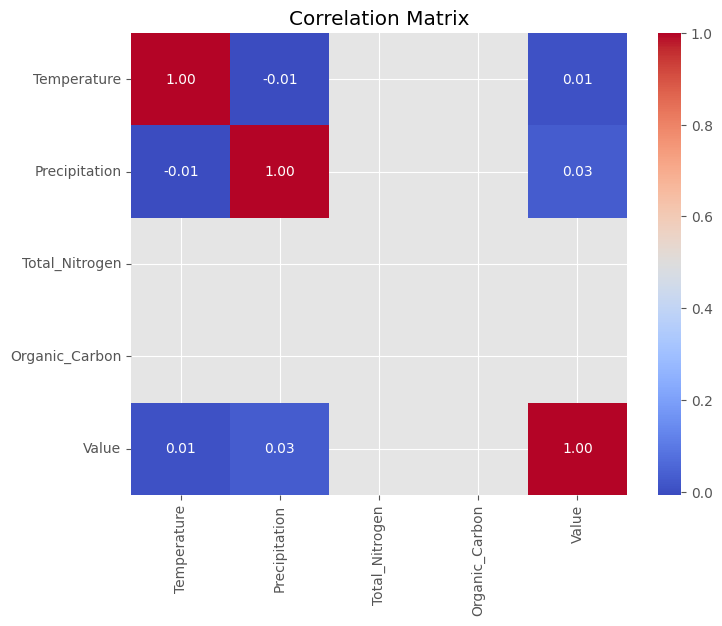

In [85]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

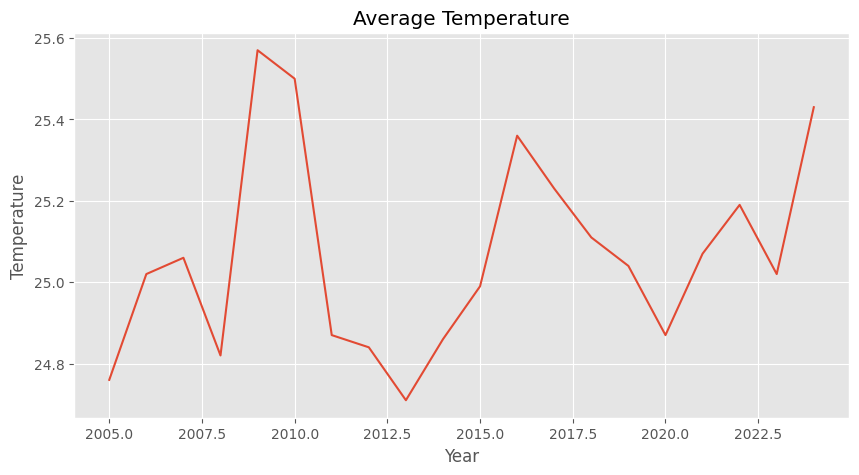

In [86]:
temp = final_df.groupby("Year")["Temperature"].mean()

plt.figure(figsize=(10,5))

plt.plot(temp.index, temp.values)

plt.title("Average Temperature")

plt.xlabel("Year")

plt.ylabel("Temperature")

plt.grid(True)

plt.show()

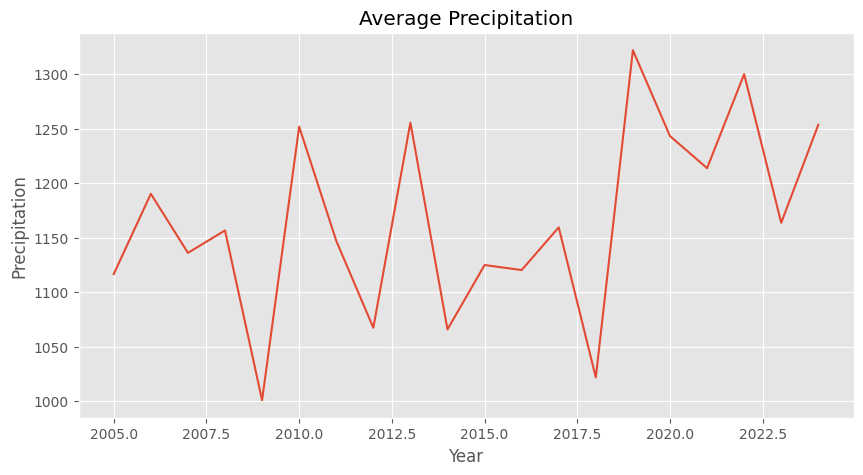

In [87]:
rain = final_df.groupby("Year")["Precipitation"].mean()

plt.figure(figsize=(10,5))

plt.plot(rain.index, rain.values)

plt.title("Average Precipitation")

plt.xlabel("Year")

plt.ylabel("Precipitation")

plt.grid(True)

plt.show()

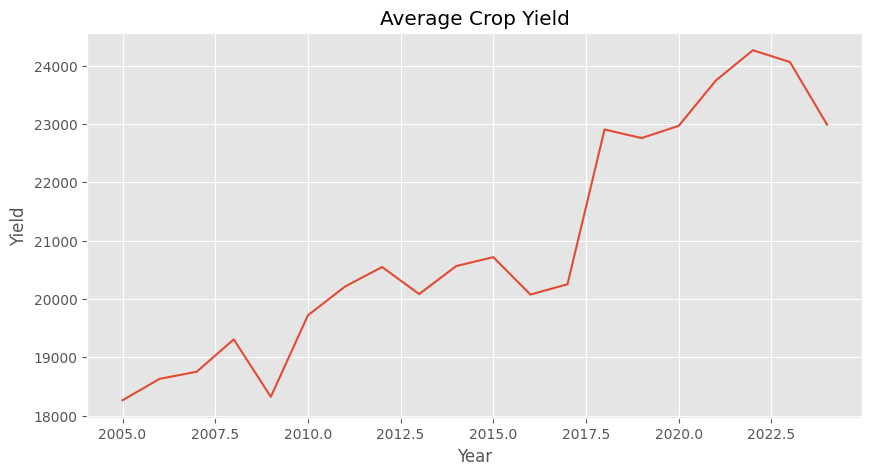

In [88]:
yield_df = final_df[
    final_df["Element"] == "Yield"
]

yield_year = (
    yield_df.groupby("Year")["Value"]
    .mean()
)

plt.figure(figsize=(10,5))

plt.plot(
    yield_year.index,
    yield_year.values
)

plt.title("Average Crop Yield")

plt.xlabel("Year")

plt.ylabel("Yield")

plt.grid(True)

plt.show()

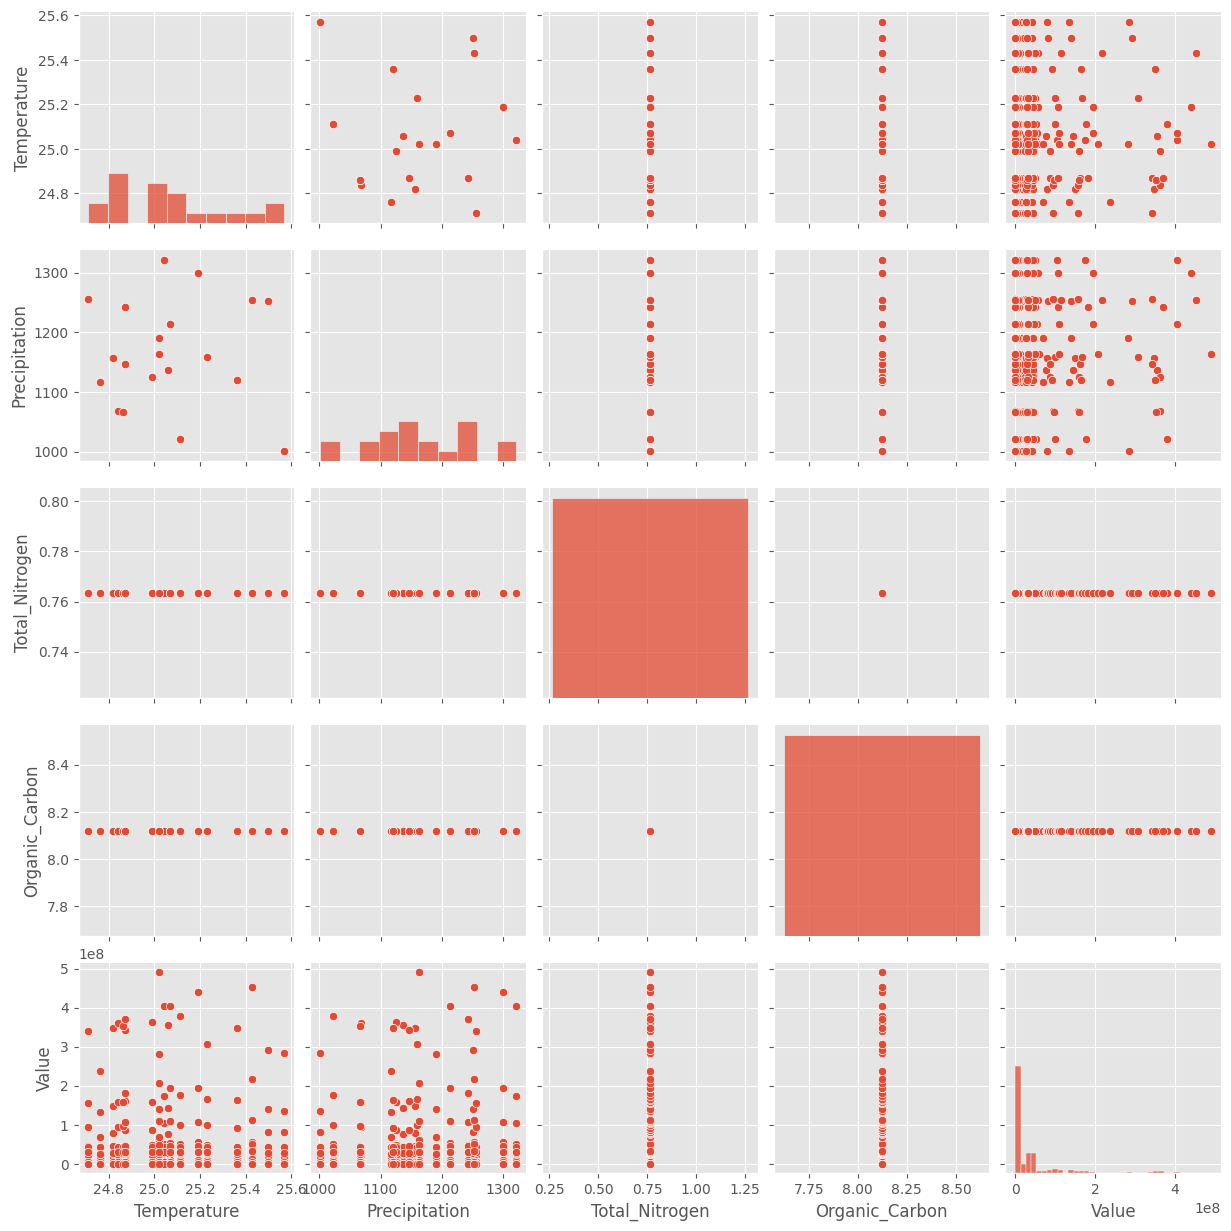

In [89]:
sns.pairplot(
    final_df[
        [
            "Temperature",
            "Precipitation",
            "Total_Nitrogen",
            "Organic_Carbon",
            "Value"
        ]
    ]
)

plt.show()

In [90]:
final_df.to_csv(
    "Final_Integrated_Dataset.csv",
    index=False
)

In [91]:
print("Final dataset shape:", final_df.shape)
print("Number of features:", final_df.shape[1])
print("Years:", final_df["Year"].min(), "-", final_df["Year"].max())
print("Country:", final_df["Area"].unique())

Final dataset shape: (300, 20)
Number of features: 20
Years: 2005 - 2024
Country: ['India']


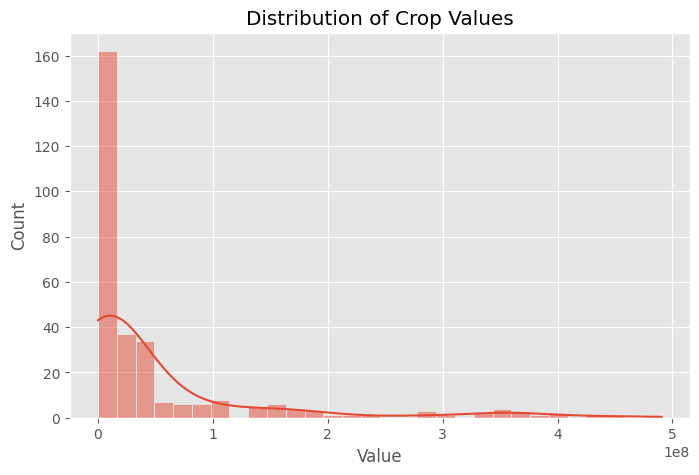

In [92]:
plt.figure(figsize=(8,5))
sns.histplot(final_df["Value"], bins=30, kde=True)

plt.title("Distribution of Crop Values")
plt.xlabel("Value")
plt.show()

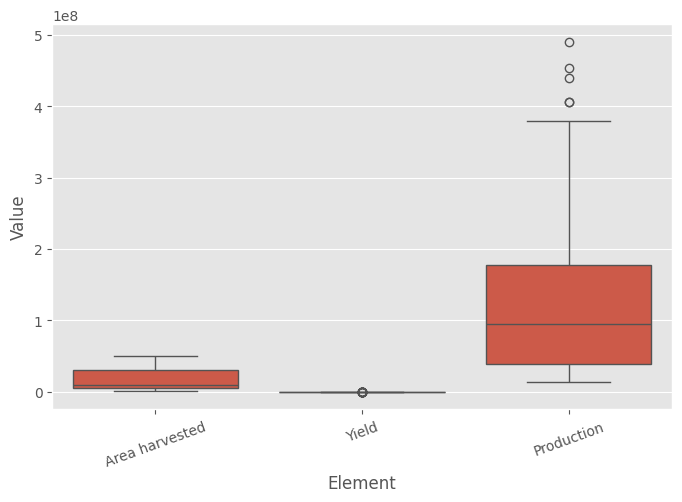

In [93]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=final_df,
    x="Element",
    y="Value"
)

plt.xticks(rotation=20)
plt.show()

In [94]:
final_df.to_csv("Final_Integrated_Dataset.csv", index=False)

In [95]:
ml_df = final_df[
    final_df["Element"] == "Yield"
].copy()

print(ml_df.shape)

ml_df.head()

(100, 20)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note,code,Temperature,Precipitation,Total_Nitrogen,Organic_Carbon
1,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2005,2005,kg/ha,1955.7,A,Official figure,NaN,IND,24.76,1116.64,0.763468,8.120833
4,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2006,2006,kg/ha,1811.1,A,Official figure,NaN,IND,25.02,1190.24,0.763468,8.120833
7,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2007,2007,kg/ha,2315.8,A,Official figure,NaN,IND,25.06,1136.08,0.763468,8.120833
10,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2008,2008,kg/ha,2276.5,A,Official figure,NaN,IND,24.82,1156.62,0.763468,8.120833
13,QCL,Crops and livestock products,356,India,5412,Yield,112,Maize (corn),2009,2009,kg/ha,2146.1,A,Official figure,NaN,IND,25.57,1001.00,0.763468,8.120833


In [96]:
drop_cols = [
    "Domain Code",
    "Domain",
    "Area Code (M49)",
    "Element Code",
    "Element",
    "Item Code (CPC)",
    "Year Code",
    "Unit",
    "Flag",
    "Flag Description",
    "Note",
    "code"
]

ml_df = ml_df.drop(columns=drop_cols)

ml_df.head()

,Area,Item,Year,Value,Temperature,Precipitation,Total_Nitrogen,Organic_Carbon
1,India,Maize (corn),2005,1955.7,24.76,1116.64,0.763468,8.120833
4,India,Maize (corn),2006,1811.1,25.02,1190.24,0.763468,8.120833
7,India,Maize (corn),2007,2315.8,25.06,1136.08,0.763468,8.120833
10,India,Maize (corn),2008,2276.5,24.82,1156.62,0.763468,8.120833
13,India,Maize (corn),2009,2146.1,25.57,1001.00,0.763468,8.120833


In [97]:
ml_df.info()

ml_df.head()

<class 'pandas.core.frame.DataFrame'>
Index: 100 entries, 1 to 298
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Area            100 non-null    object 
 1   Item            100 non-null    object 
 2   Year            100 non-null    int64  
 3   Value           100 non-null    float64
 4   Temperature     100 non-null    float64
 5   Precipitation   100 non-null    float64
 6   Total_Nitrogen  100 non-null    float64
 7   Organic_Carbon  100 non-null    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 11.1+ KB


,Area,Item,Year,Value,Temperature,Precipitation,Total_Nitrogen,Organic_Carbon
1,India,Maize (corn),2005,1955.7,24.76,1116.64,0.763468,8.120833
4,India,Maize (corn),2006,1811.1,25.02,1190.24,0.763468,8.120833
7,India,Maize (corn),2007,2315.8,25.06,1136.08,0.763468,8.120833
10,India,Maize (corn),2008,2276.5,24.82,1156.62,0.763468,8.120833
13,India,Maize (corn),2009,2146.1,25.57,1001.00,0.763468,8.120833


In [98]:
from sklearn.preprocessing import LabelEncoder

le_area = LabelEncoder()
le_crop = LabelEncoder()

ml_df["Area"] = le_area.fit_transform(ml_df["Area"])

ml_df["Item"] = le_crop.fit_transform(ml_df["Item"])

ml_df.head()

,Area,Item,Year,Value,Temperature,Precipitation,Total_Nitrogen,Organic_Carbon
1,0,0,2005,1955.7,24.76,1116.64,0.763468,8.120833
4,0,0,2006,1811.1,25.02,1190.24,0.763468,8.120833
7,0,0,2007,2315.8,25.06,1136.08,0.763468,8.120833
10,0,0,2008,2276.5,24.82,1156.62,0.763468,8.120833
13,0,0,2009,2146.1,25.57,1001.00,0.763468,8.120833


In [99]:
X = ml_df.drop("Value", axis=1)

y = ml_df["Value"]

print(X.shape)
print(y.shape)

(100, 7)
(100,)


In [100]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(80, 7)
(20, 7)


In [101]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

#Random Forest

In [102]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [103]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("MAE :", mean_absolute_error(y_test, rf_pred))

print("RMSE :", np.sqrt(mean_squared_error(y_test, rf_pred)))

print("R2 :", r2_score(y_test, rf_pred))

MAE : 1375.056100000008
RMSE : 2469.4291803225065
R2 : 0.9930828300421028


#XGBoost

In [104]:
!pip install xgboost -q
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = xgb.predict(X_test)

In [105]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("XGBoost Results")
print("MAE :", mean_absolute_error(y_test, xgb_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("R2 :", r2_score(y_test, xgb_pred))

XGBoost Results
MAE : 934.9673059082039
RMSE : 1656.1727458501905
R2 : 0.9968886665201158


#CatBoost

In [106]:
!pip install catboost -q
from catboost import CatBoostRegressor

cat = CatBoostRegressor(
    iterations=200,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_seed=42
)

cat.fit(X_train, y_train)

cat_pred = cat.predict(X_test)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 5.5 MB/s eta 0:00:00


In [107]:
print("CatBoost Results")
print("MAE :", mean_absolute_error(y_test, cat_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, cat_pred)))
print("R2 :", r2_score(y_test, cat_pred))

CatBoost Results
MAE : 2684.034040982093
RMSE : 3882.1433525972607
R2 : 0.9829046328856643


#Artificial Neural Network (ANN)

In [108]:
import tensorflow as tf

ann = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)
])

ann.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

history = ann.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=8,
    validation_split=0.2,
    verbose=0
)

ann_pred = ann.predict(X_test).flatten()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step


In [109]:
print("ANN Results")
print("MAE :", mean_absolute_error(y_test, ann_pred))
print("RMSE :", np.sqrt(mean_squared_error(y_test, ann_pred)))
print("R2 :", r2_score(y_test, ann_pred))

ANN Results
MAE : 21287.59109375
RMSE : 35857.64010586372
R2 : -0.458474039374404


#Model Comparison Table

In [110]:
results = {
    "Model": [
        "Random Forest",
        "XGBoost",
        "CatBoost",
        "ANN"
    ],
    "MAE": [
        mean_absolute_error(y_test, rf_pred),
        mean_absolute_error(y_test, xgb_pred),
        mean_absolute_error(y_test, cat_pred),
        mean_absolute_error(y_test, ann_pred)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, rf_pred)),
        np.sqrt(mean_squared_error(y_test, xgb_pred)),
        np.sqrt(mean_squared_error(y_test, cat_pred)),
        np.sqrt(mean_squared_error(y_test, ann_pred))
    ],
    "R2 Score": [
        r2_score(y_test, rf_pred),
        r2_score(y_test, xgb_pred),
        r2_score(y_test, cat_pred),
        r2_score(y_test, ann_pred)
    ]
}

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Random Forest,1375.056100,2469.429180,0.993083
1,XGBoost,934.967306,1656.172746,0.996889
2,CatBoost,2684.034041,3882.143353,0.982905
3,ANN,21287.591094,35857.640106,-0.458474


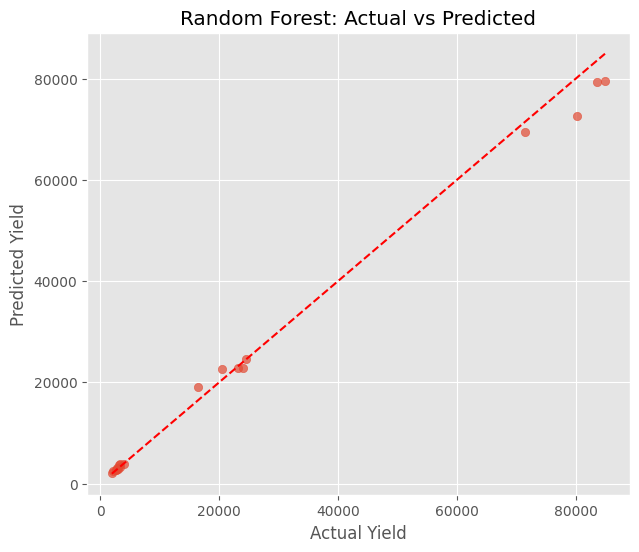

In [112]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, rf_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Random Forest: Actual vs Predicted")

plt.show()

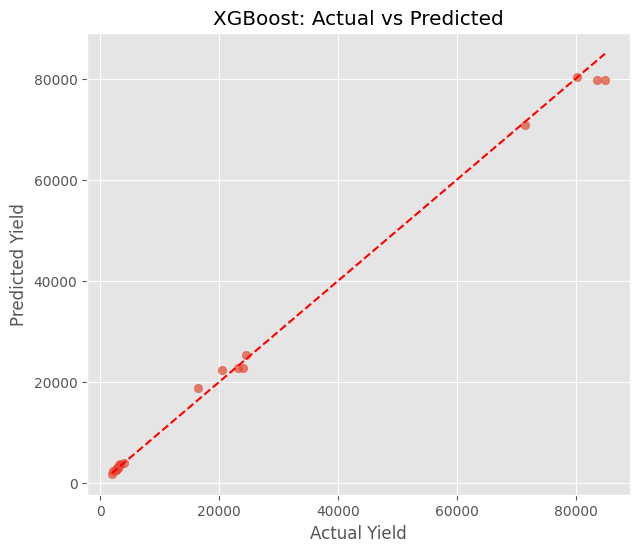

In [113]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, xgb_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("XGBoost: Actual vs Predicted")

plt.show()

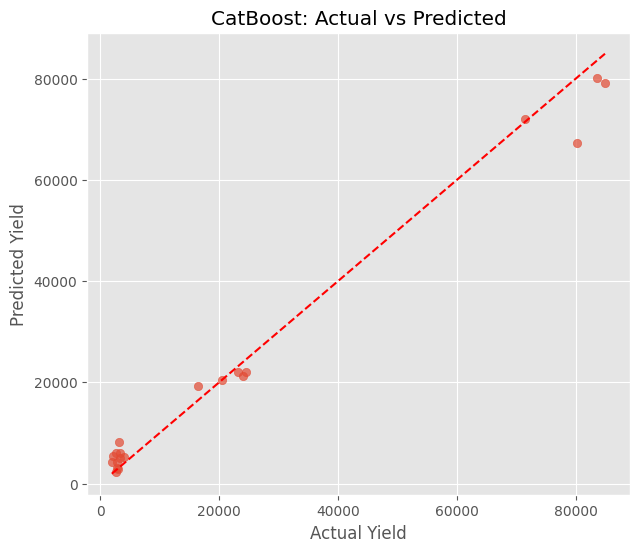

In [114]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, cat_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("CatBoost: Actual vs Predicted")

plt.show()

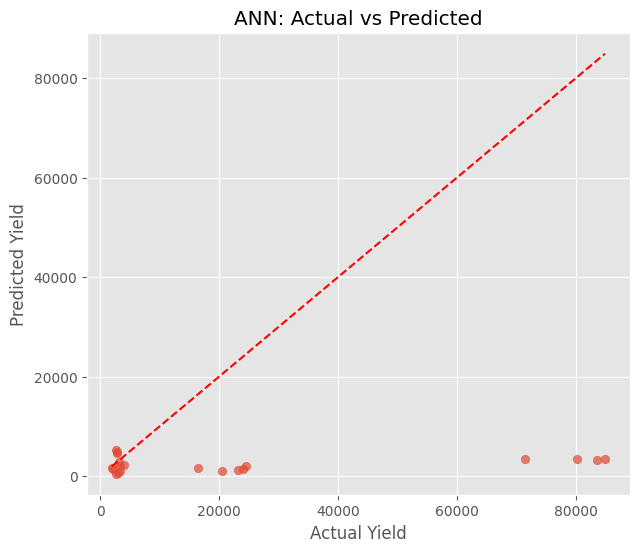

In [115]:
plt.figure(figsize=(7,6))

plt.scatter(y_test, ann_pred, alpha=0.7)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("ANN: Actual vs Predicted")

plt.show()

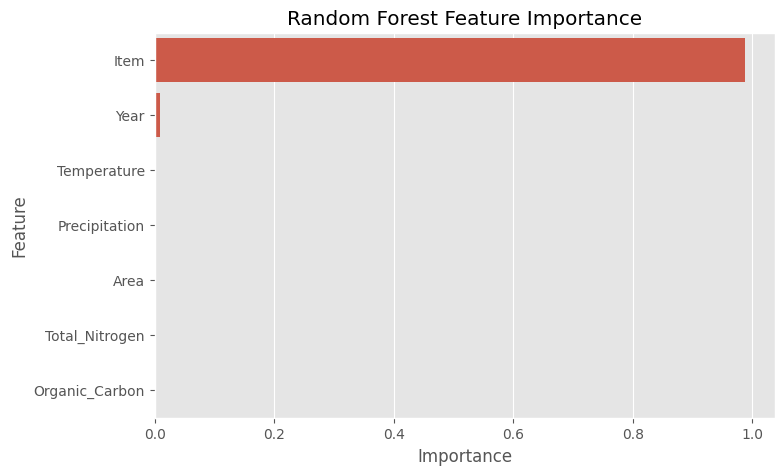

In [116]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")

plt.show()

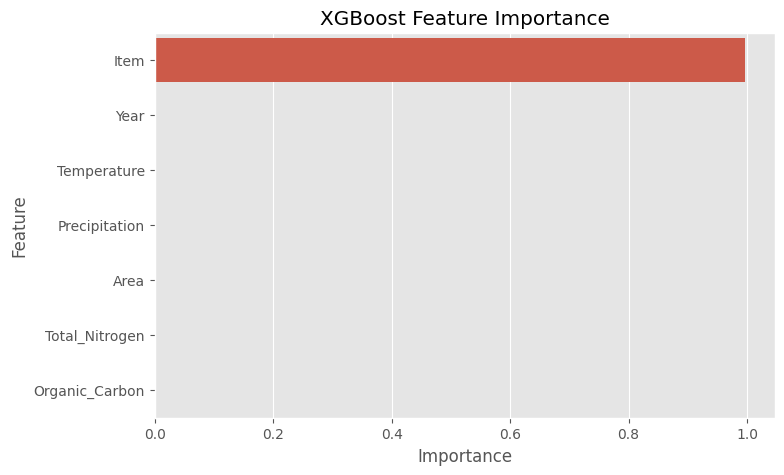

In [117]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("XGBoost Feature Importance")

plt.show()

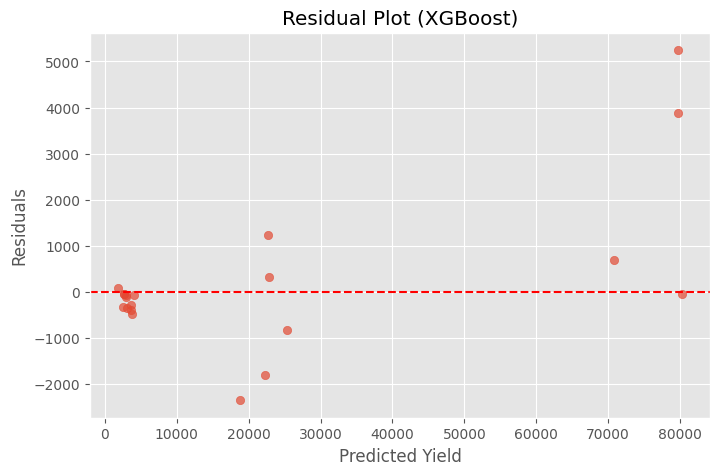

In [118]:
residuals = y_test - xgb_pred

plt.figure(figsize=(8,5))

plt.scatter(
    xgb_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    color='red',
    linestyle='--'
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")

plt.title("Residual Plot (XGBoost)")

plt.show()

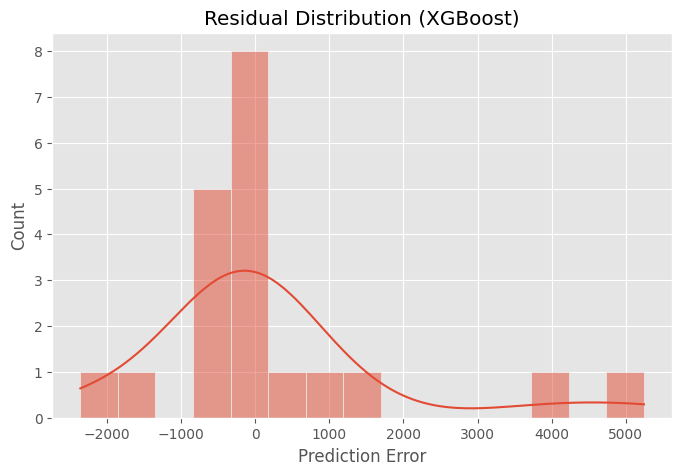

In [119]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    bins=15,
    kde=True
)

plt.title("Residual Distribution (XGBoost)")

plt.xlabel("Prediction Error")

plt.show()

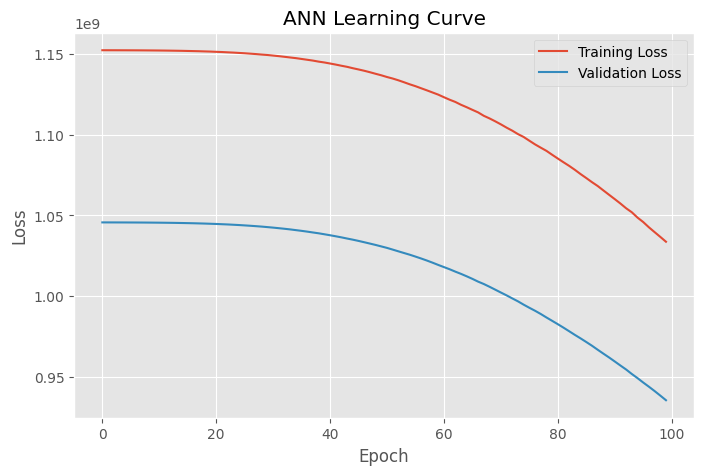

In [120]:
plt.figure(figsize=(8,5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("ANN Learning Curve")

plt.legend()

plt.show()

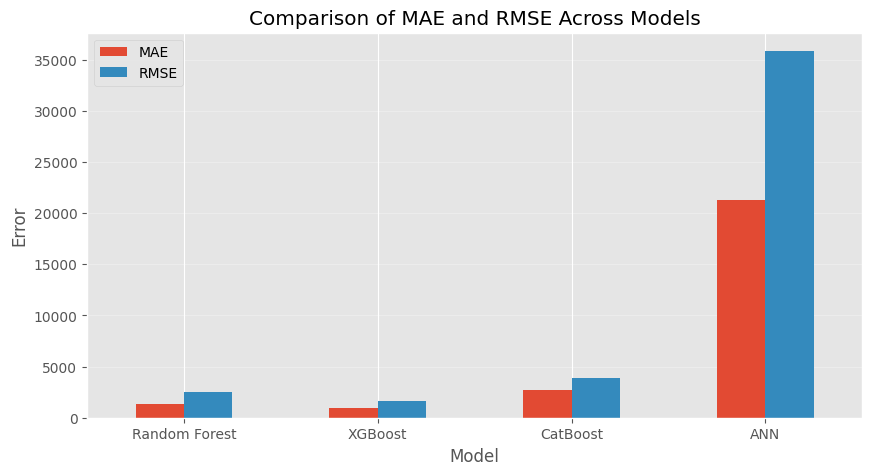

In [121]:
import numpy as np

comparison = results_df.set_index("Model")[["MAE","RMSE"]]

comparison.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Comparison of MAE and RMSE Across Models")
plt.ylabel("Error")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

#Best Model

In [111]:
best_model = results_df.loc[
    results_df["R2 Score"].idxmax()
]

print(best_model)

Model           XGBoost
MAE          934.967306
RMSE        1656.172746
R2 Score       0.996889
Name: 1, dtype: object


In [122]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

[ -1643.7271903     -59.42169291  -2238.29368808   -115.24512595
 -47010.64373241]
-10213.466285929095


In [123]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    xgb,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print("Mean R²:", scores.mean())

[ -1643.7271903     -59.42169291  -2238.29368808   -115.24512595
 -47010.64373241]
Mean R²: -10213.466285929095


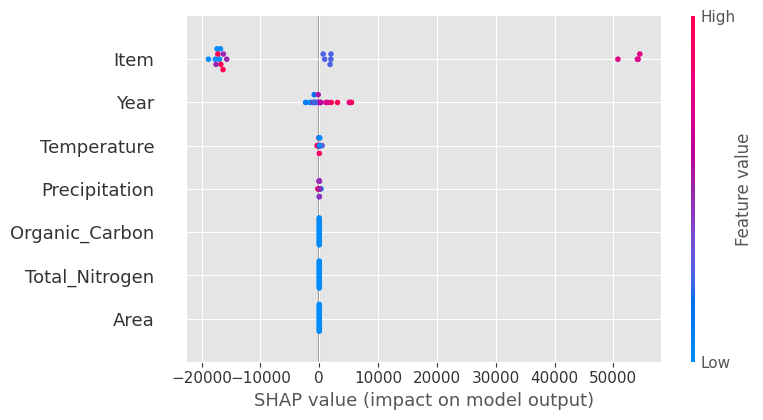

In [124]:
!pip install shap -q

import shap

explainer = shap.TreeExplainer(xgb)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

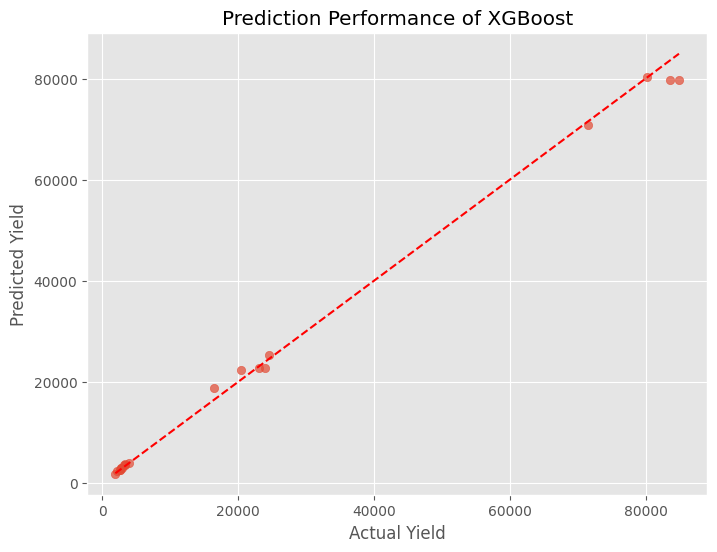

In [125]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    xgb_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title("Prediction Performance of XGBoost")

plt.show()